In [1]:
import pandas as pd

# Load the dataset
df = pd.read_pickle('data/LSWMD.pkl')

# Basic info
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()

Shape: (811457, 6)

Columns: ['waferMap', 'dieSize', 'lotName', 'waferIndex', 'trianTestLabel', 'failureType']


,waferMap,dieSize,lotName,waferIndex,trianTestLabel,failureType
0,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,1.0,[[Training]],[[none]]
1,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,2.0,[[Training]],[[none]]
2,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,3.0,[[Training]],[[none]]
3,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,4.0,[[Training]],[[none]]
4,"[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,...",1683.0,lot1,5.0,[[Training]],[[none]]


In [2]:
# Check how many wafers actually have a failure type label
def get_label_len(x):
    if len(x) == 0:
        return 0
    return len(x[0]) if hasattr(x[0], '__len__') else 1

df['label_len'] = df['failureType'].apply(lambda x: len(x))
labelled_df = df[df['label_len'] != 0]

print("Total wafers:", len(df))
print("Labelled wafers:", len(labelled_df))
print("Unlabelled wafers:", len(df) - len(labelled_df))

Total wafers: 811457
Labelled wafers: 172950
Unlabelled wafers: 638507


In [3]:
# Extract actual failure type name from each labelled row
def extract_label(x):
    if len(x) == 0:
        return None
    val = x[0][0] if hasattr(x[0], '__len__') else x[0]
    return val

labelled_df['label'] = labelled_df['failureType'].apply(extract_label)

# Count how many samples per class
print(labelled_df['label'].value_counts())

label
none         147431
Edge-Ring      9680
Edge-Loc       5189
Center         4294
Loc            3593
Scratch        1193
Random          866
Donut           555
Near-full       149
Name: count, dtype: int64


C:\Users\capit\AppData\Local\Temp\ipykernel_13188\2629808765.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled_df['label'] = labelled_df['failureType'].apply(extract_label)


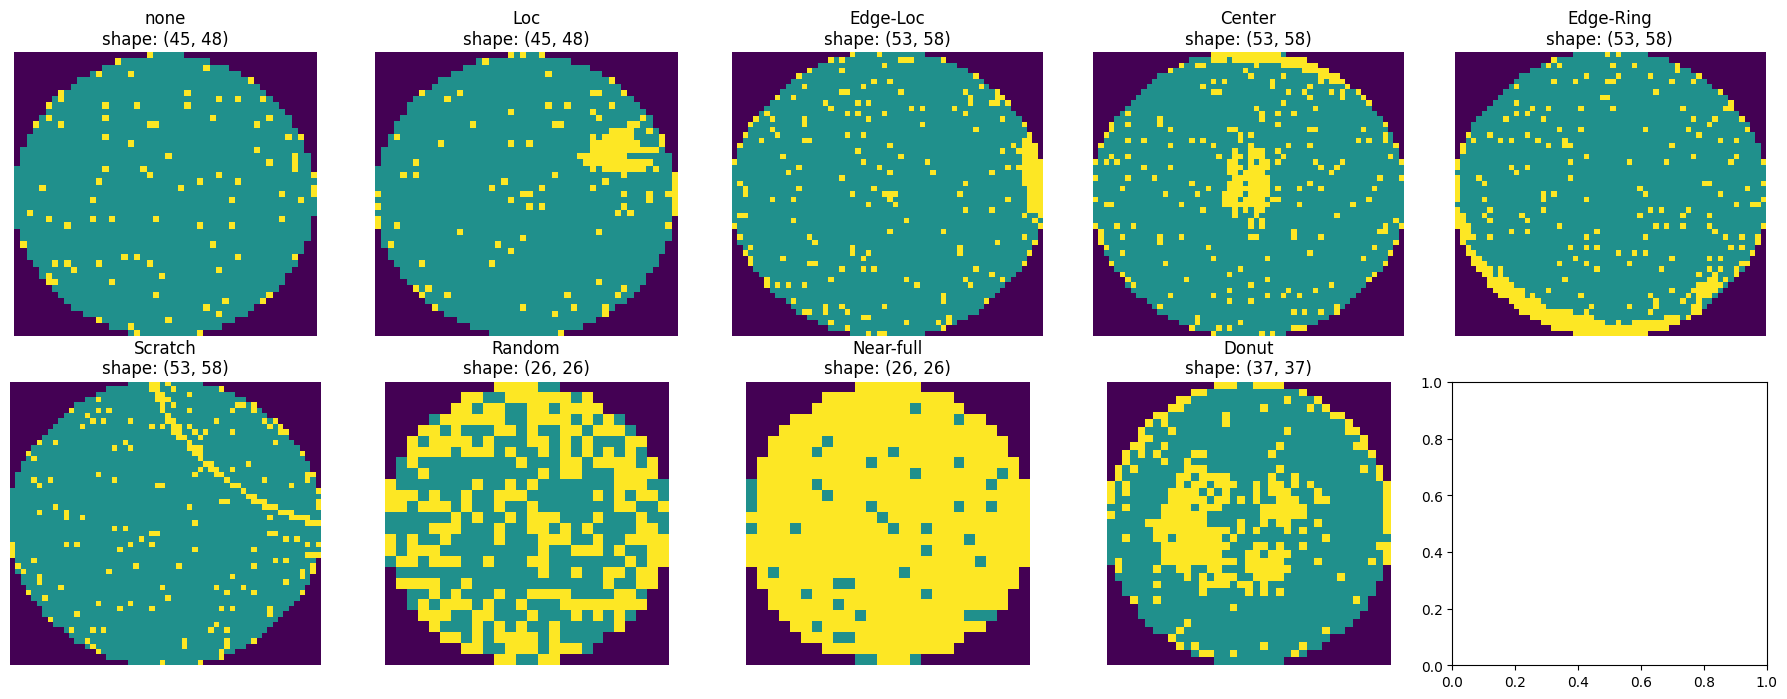

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Pick one sample from each defect class to visualize
classes = labelled_df['label'].unique()
fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, cls in enumerate(classes):
    sample = labelled_df[labelled_df['label'] == cls].iloc[0]
    wafer = sample['waferMap']
    axes[i].imshow(wafer, cmap='viridis')
    axes[i].set_title(f"{cls}\nshape: {wafer.shape}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

Original shape: (45, 48)
Resized shape: (64, 64)


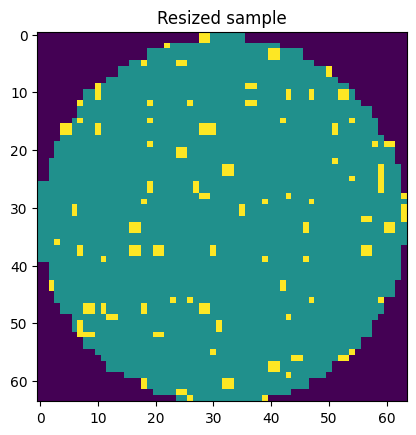

In [5]:
import cv2

def resize_wafer(wafer_map, size=(64, 64)):
    wafer_map = np.array(wafer_map, dtype=np.uint8)
    resized = cv2.resize(wafer_map, size, interpolation=cv2.INTER_NEAREST)
    return resized

# Test on one sample
sample = labelled_df.iloc[0]['waferMap']
print("Original shape:", sample.shape)
resized = resize_wafer(sample)
print("Resized shape:", resized.shape)

plt.imshow(resized, cmap='viridis')
plt.title("Resized sample")
plt.show()

In [6]:
from sklearn.utils import resample

# Step 1: Resize ALL labelled wafers first
print("Resizing all wafers...")
labelled_df['resized'] = labelled_df['waferMap'].apply(lambda x: resize_wafer(x))

# Step 2: Undersample 'none' class
none_df = labelled_df[labelled_df['label'] == 'none']
other_df = labelled_df[labelled_df['label'] != 'none']

none_sampled = resample(none_df, replace=False, n_samples=10000, random_state=42)

# Step 3: Combine back
balanced_df = pd.concat([none_sampled, other_df])

print("\nBefore balancing (other classes):")
print(other_df['label'].value_counts())
print("\nAfter undersampling 'none':")
print(balanced_df['label'].value_counts())

Resizing all wafers...

Before balancing (other classes):
label
Edge-Ring    9680
Edge-Loc     5189
Center       4294
Loc          3593
Scratch      1193
Random        866
Donut         555
Near-full     149
Name: count, dtype: int64

After undersampling 'none':
label
none         10000
Edge-Ring     9680
Edge-Loc      5189
Center        4294
Loc           3593
Scratch       1193
Random         866
Donut          555
Near-full      149
Name: count, dtype: int64


C:\Users\capit\AppData\Local\Temp\ipykernel_13188\461810438.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  labelled_df['resized'] = labelled_df['waferMap'].apply(lambda x: resize_wafer(x))


In [7]:
def augment_wafer(wafer_map):
    """Randomly rotate or flip a wafer map to create a new sample"""
    choice = np.random.choice(['rot90', 'rot180', 'rot270', 'flip_h', 'flip_v'])
    if choice == 'rot90':
        return np.rot90(wafer_map, 1)
    elif choice == 'rot180':
        return np.rot90(wafer_map, 2)
    elif choice == 'rot270':
        return np.rot90(wafer_map, 3)
    elif choice == 'flip_h':
        return np.fliplr(wafer_map)
    else:
        return np.flipud(wafer_map)

def oversample_class(df, label, target_count):
    class_df = df[df['label'] == label]
    current_count = len(class_df)
    if current_count >= target_count:
        return class_df
    
    needed = target_count - current_count
    augmented_rows = []
    for i in range(needed):
        row = class_df.sample(1, random_state=i).iloc[0].copy()
        row['resized'] = augment_wafer(row['resized'])
        augmented_rows.append(row)
    
    augmented_df = pd.DataFrame(augmented_rows)
    return pd.concat([class_df, augmented_df])

# Apply oversampling to minority classes
target = 2500
minority_classes = ['Scratch', 'Random', 'Donut', 'Near-full']

final_parts = [balanced_df[~balanced_df['label'].isin(minority_classes)]]
for cls in minority_classes:
    final_parts.append(oversample_class(balanced_df, cls, target))

final_df = pd.concat(final_parts).reset_index(drop=True)

print("Final class distribution:")
print(final_df['label'].value_counts())

Final class distribution:
label
none         10000
Edge-Ring     9680
Edge-Loc      5189
Center        4294
Loc           3593
Scratch       2500
Random        2500
Donut         2500
Near-full     2500
Name: count, dtype: int64


In [8]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Convert resized wafer maps to a proper numpy array (X) and labels (y)
X = np.stack(final_df['resized'].values)
X = X.reshape(-1, 64, 64, 1).astype('float32') / 3.0   # normalize (values are 0,1,2 -> scale to 0-1)

le = LabelEncoder()
y = le.fit_transform(final_df['label'].values)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Classes:", le.classes_)

# Train/val/test split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print("\nTrain:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)

# Save for later use (so we don't have to redo preprocessing every time)
np.savez('data/processed_data.npz', 
         X_train=X_train, y_train=y_train,
         X_val=X_val, y_val=y_val,
         X_test=X_test, y_test=y_test,
         classes=le.classes_)

print("\nSaved to data/processed_data.npz")

X shape: (42756, 64, 64, 1)
y shape: (42756,)
Classes: [np.str_('Center') np.str_('Donut') np.str_('Edge-Loc')
 np.str_('Edge-Ring') np.str_('Loc') np.str_('Near-full')
 np.str_('Random') np.str_('Scratch') np.str_('none')]

Train: (29929, 64, 64, 1) Val: (6413, 64, 64, 1) Test: (6414, 64, 64, 1)

Saved to data/processed_data.npz
